Loading Global Baseline...
Baseline loaded. Intercepts: 1342998, Factors: 1342998
Preparing deep analysis for 38 topics...
  [21/38] Extracting dual-dimension data: 304_-_Political_Corruption ...e ..._Negative ......
Successfully analyzed 15 topics. Generating charts...


C:\Users\yuanxili\AppData\Local\Temp\ipykernel_18956\3614789946.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot1, x='intercept_distance', y='topic', ax=ax1, palette='magma')
C:\Users\yuanxili\AppData\Local\Temp\ipykernel_18956\3614789946.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot2, x='factor_distance', y='topic', ax=ax2, palette='mako')


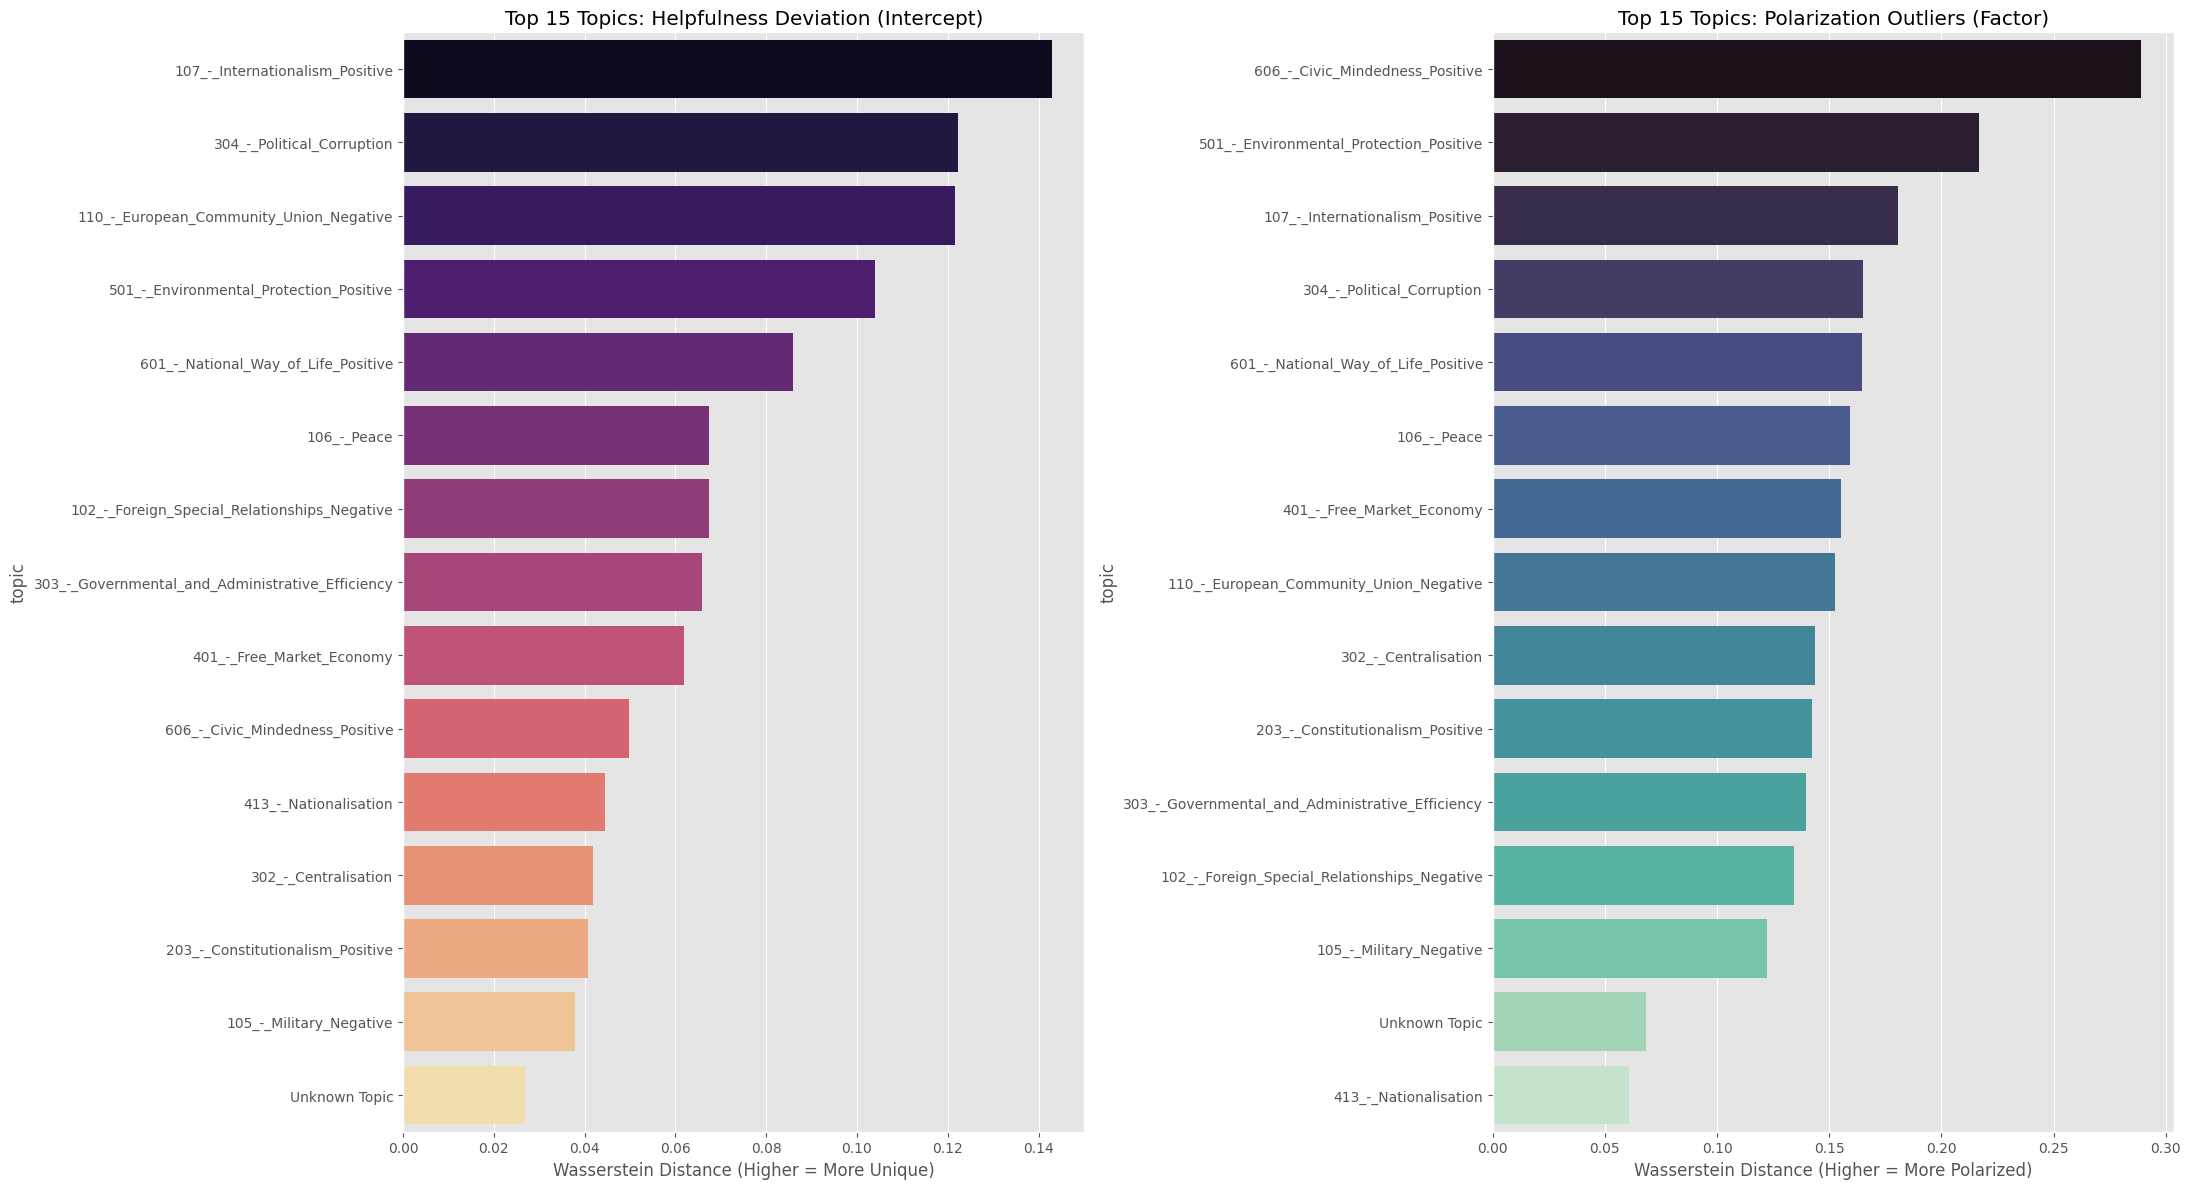


--- Summary: Top 5 Polarization Outliers ---
                                      topic  factor_distance  \
12          606_-_Civic_Mindedness_Positive         0.289164   
4   501_-_Environmental_Protection_Positive         0.216960   
7           107_-_Internationalism_Positive         0.180871   
14               304_-_Political_Corruption         0.164840   
0       601_-_National_Way_of_Life_Positive         0.164482   

    intercept_distance  note_count  
12            0.049748         214  
4             0.103946          54  
7             0.142974          11  
14            0.122225          29  
0             0.085982         217  


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

# 1. Load the Global Baseline (The "Anchor" for comparison)
baseline_file = 'prescoringNoteModelOutput_1dim.tsv'
print(f"Loading Global Baseline...")
global_results = pd.read_csv(baseline_file, sep='\t')
# Extract global intercepts (Note Quality) and factors (Note Viewpoint/Polarization)
g_intercepts = global_results['internalNoteIntercept'].dropna()
g_factors = global_results['internalNoteFactor1'].dropna()
print(f"Baseline loaded. Intercepts: {len(g_intercepts)}, Factors: {len(g_factors)}")

output_root = "output_by_topic"
topic_stats = []

# 2. Identify all processed topic folders
topics = [f for f in os.listdir(output_root) if os.path.isdir(os.path.join(output_root, f))]

print(f"Preparing analysis for {len(topics)} topics...")

# 3. Iterate through topics and calculate statistical distances
for i, topic in enumerate(topics):
    # Safety Check: Match either of the two common output filenames
    possible_files = [
        os.path.join(output_root, topic, "prescoringNoteModelOutput_1dim.tsv"),
        os.path.join(output_root, topic, "scored_notes.tsv")
    ]
    
    # Select the first file that actually exists
    file_path = next((p for p in possible_files if os.path.exists(p)), None)
    if file_path is None: 
        continue
        
    print(f"  [{i+1}/{len(topics)}] Extracting dual-dimension data: {topic} ...", end="\r")
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        
        # Verify that required columns exist in the topic output
        if 'internalNoteIntercept' not in df.columns or 'internalNoteFactor1' not in df.columns:
            continue
            
        t_intercepts = df['internalNoteIntercept'].dropna()
        t_factors = df['internalNoteFactor1'].dropna()
        
        # Threshold: Topic must have at least 1 valid note to calculate distance
        if len(t_intercepts) >= 1 and len(t_factors) >= 1:
            # Calculate Wasserstein Distance (EMD) for both Helpfulness and Polarization
            dist_intercept = wasserstein_distance(g_intercepts, t_intercepts)
            dist_factor = wasserstein_distance(g_factors, t_factors)
            
            topic_stats.append({
                'topic': topic if str(topic) != 'nan' else 'Unknown Topic',
                'intercept_distance': dist_intercept,
                'factor_distance': dist_factor,
                'mean_intercept': t_intercepts.mean(),
                'note_count': len(df)
            })
    except Exception as e:
        print(f"\nSkipping topic {topic} due to error: {e}")

print("\n" + "="*40)

# 4. Final Output and Visualization
stats_df = pd.DataFrame(topic_stats)
print(f"Successfully analyzed {len(stats_df)} topics. Generating charts...")

# Set visualization style
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 12))

# Plot A: Helpfulness Deviation (How much 'consensus' varies from the site average)
df_plot1 = stats_df.sort_values('intercept_distance', ascending=False).head(15)
sns.barplot(data=df_plot1, x='intercept_distance', y='topic', ax=ax1, palette='magma')
ax1.set_title('Top 15 Topics: Helpfulness Deviation (Intercept)')
ax1.set_xlabel('Wasserstein Distance (Higher = More Unique)')

# Plot B: Polarization Outliers (Where ideological fighting is most intense)
# This measures the "spread" of viewpoints compared to the global norm.
df_plot2 = stats_df.sort_values('factor_distance', ascending=False).head(15)
sns.barplot(data=df_plot2, x='factor_distance', y='topic', ax=ax2, palette='mako')
ax2.set_title('Top 15 Topics: Polarization Outliers (Factor)')
ax2.set_xlabel('Wasserstein Distance (Higher = More Polarized)')

plt.tight_layout()
plt.show()

# Print Summary Table for the Top 5 most polarized topics
print("\n--- Summary: Top 5 Polarization Outliers ---")
print(stats_df.sort_values('factor_distance', ascending=False)[['topic', 'factor_distance', 'intercept_distance', 'note_count']].head())